# Importación de librerías

In [9]:
import pytesseract
from pytesseract import Output
from pdf2image import convert_from_path
import pandas as pd
from PIL import Image, ImageFilter, ImageDraw
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

In [ ]:
# Configuración de idioma para Tesseract
TESSERACT_LANG = 'spa'

# 1. Apunta al ejecutable de Tesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# 2. Apunta a la carpeta BIN de Poppler
# (Si pusiste poppler en otra ruta, cámbiala aquí)
ruta_poppler = r'C:\Users\Blordoh\Documents\poppler-25.12.0\Library\bin' 

# Funciones OCR

## OCR de la primera parte de la tabla

In [11]:
def ocr_pagina_uno(num_pagina):
    PAGINA_A_PROCESAR = num_pagina
    DPI_ESCALA = 400 
    PIXEL_CORTE_SUPERIOR = 780 
    PIXEL_CORTE_INFERIOR = -460
    NOMBRES_COLS = ['sector','estacion','fecha','bateria','aluminio_total',
                    'arsenico_total','aceite_y_grasas','boro_total','bromo_total',
                    'calcio_total','cadmio_total','cloruros','carbonatos','coliformes_totales',
                    'cromo_total','conductividad_a_25_grados','cobre_total','demanda_bioquimica_o2',
                    'detergente','demanda_quimica_o2','fluor_total','hierro_total','bicarbonatos',
                    'hidrocarburos_ciclicos']

    # --- 2. PREPARACIÓN DE IMAGEN ---
    print(f"Cargando página {PAGINA_A_PROCESAR}...")
    imagenes = convert_from_path(ruta_pdf, dpi=DPI_ESCALA, first_page=PAGINA_A_PROCESAR, last_page=PAGINA_A_PROCESAR, poppler_path=ruta_poppler)
    img_np = np.array(imagenes[0]) 

    if len(img_np.shape) == 3:
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_np

    # --- 3. DETECCIÓN DE REJILLA MEJORADA (ADAPTATIVE THRESHOLD) ---
    #print("2. Detectando líneas verticales (Modo Alta Sensibilidad)...")

    # CAMBIO 1: Usamos Adaptive Threshold. 
    # Esto es mucho mejor para tablas con encabezados grises o sombras.
    # Detecta bordes locales en lugar de globales.
    thresh = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                cv2.THRESH_BINARY_INV, 11, 2)

    # CAMBIO 2: Kernel más pequeño para detectar líneas rotas
    # Antes usábamos (1, 50), ahora (1, 20). Detecta segmentos más cortos.
    kernel_vert = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))
    lineas_vert = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_vert, iterations=2)

    # Analizar proyección vertical
    suma_vertical = np.sum(lineas_vert, axis=0)

    # CAMBIO 3: Umbral de detección mucho más bajo
    # Antes era 0.1 (10% de altura). Ahora 0.01 (1% de altura).
    # Basta con que haya un trozo de línea vertical para que cuente.
    altura_imagen = img_np.shape[0]
    umbral_deteccion = altura_imagen * 0.01 
    indices_lineas = np.where(suma_vertical > umbral_deteccion)[0]

    # Agrupación de líneas cercanas (Grosor de línea)
    limites_detectados = []
    if len(indices_lineas) > 0:
        grupo_actual = [indices_lineas[0]]
        for x in indices_lineas[1:]:
            # Si el pixel está a menos de 15px del anterior, es parte de la misma línea gruesa
            if x - grupo_actual[-1] < 15: 
                grupo_actual.append(x)
            else:
                centro = int(np.mean(grupo_actual))
                limites_detectados.append(centro)
                grupo_actual = [x]
        limites_detectados.append(int(np.mean(grupo_actual)))

    # Limpieza de bordes extremos
    ancho_imagen = img_np.shape[1]
    # Filtramos líneas que estén demasiado pegadas al borde (ruido) o muy pegadas entre sí
    limites_finales = [0] # Empezamos en 0
    ultimo_agregado = 0
    MIN_ANCHO_COLUMNA = 20 # Pixeles mínimos entre columnas

    for x in limites_detectados:
        if x > MIN_ANCHO_COLUMNA and x < (ancho_imagen - MIN_ANCHO_COLUMNA):
            if (x - ultimo_agregado) > MIN_ANCHO_COLUMNA:
                limites_finales.append(x)
                ultimo_agregado = x

    limites_finales.append(ancho_imagen) # Terminamos al final

    print(f"--- ¡DETECTADO! Se encontraron {len(limites_finales)-1} columnas ---")

    # --- 4. VISUALIZACIÓN DE DEBUG (¡IMPORTANTE!) ---
    # Vamos a dibujar las líneas detectadas sobre la imagen original para que verifiques
    # img_debug = Image.fromarray(img_np)
    # draw = ImageDraw.Draw(img_debug)
    # for x in limites_finales:
    #     # Dibujamos línea roja vertical en cada corte detectado
    #     draw.line([(x, 0), (x, img_debug.height)], fill="red", width=3)

    # img_debug.save("debug_rejilla_detectada_p1.jpg")
    # print("-> Revisa 'debug_rejilla_detectada.jpg'. Las líneas rojas deben separar perfectamente las columnas.")

    # --- 5. BORRADO DE LÍNEAS Y EXTRACCIÓN ---
    #print("3. Borrando líneas y extrayendo datos...")

    # Borrar líneas Horizontales y Verticales para el OCR
    kernel_hori = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    lineas_hori = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_hori, iterations=2)
    mascara_total = cv2.add(lineas_hori, lineas_vert)
    # "Dilatamos" un poco la máscara para asegurar que borre los bordes sucios de las líneas
    mascara_total = cv2.dilate(mascara_total, np.ones((3,3), np.uint8), iterations=1)
    img_sin_lineas = cv2.add(img_gray, mascara_total)

    # Recorte final
    img_pil = Image.fromarray(img_sin_lineas)
    corte_abajo = img_pil.height + PIXEL_CORTE_INFERIOR 
    img_recortada = img_pil.crop((0, PIXEL_CORTE_SUPERIOR, img_pil.width, corte_abajo))

    # OCR
    d = pytesseract.image_to_data(img_recortada, lang=TESSERACT_LANG, output_type=Output.DICT, config='--psm 6')
    df = pd.DataFrame(d)
    df = df[df['conf'] != '-1']
    df = df[df['text'].str.strip() != '']

    # --- 6. CONSTRUCCIÓN tabla_uno ---
    # Eliminar columna del final (es ruido)
    limites_finales.pop()

    # Ejemplo para la función que procesa la página problemática
    # ... [Todo tu código anterior para cargar imagen, detectar columnas con reja, OCR con pytesseract] ...
    # Supongamos que 'df' es tu DataFrame crudo con las palabras detectadas y sus coordenadas ('top', 'left', etc.)
    print(f"{len(limites_detectados)}-{len(limites_finales)}")
    # --- LÓGICA DE FILAS NUEVA (Geométrica) ---
    print("   -> Asignando filas basadas en geometría...")
    # Llamamos a la función auxiliar. El umbral de 15px debería estar bien, si no, súbelo a 20.
    df = asignar_filas_por_pixeles(df, umbral_salto=15)


    # --- LÓGICA DE COLUMNAS (Tu lógica actual con pd.cut y los límites detectados) ---
    #NOMBRES_COLS = [f"Col_{i+1}" for i in range(len(limites_detectados) - 1)]
    # Supongamos que 'limites_detectados' y 'nombres_cols' ya los tienes de la detección de reja
    df['x_group'] = pd.cut(df['left'], bins=limites_finales, labels=NOMBRES_COLS)

    # --- CREAR LA TABLA FINAL (Pivot) ---
    print("   -> Creando tabla_uno dinámica...")
    # CAMBIO CLAVE: Usamos 'fila_geometrica' como índice
    tabla_uno = df.pivot_table(index='fila_geometrica', 
                           columns='x_group', 
                           values='text', 
                           aggfunc=lambda x: ' '.join(x.dropna().astype(str)), 
                           observed=False)

    # --- PASOS FINALES IMPORTANTES ---
    # 1. Asegurar todas las columnas (incluso las vacías)
    tabla_uno = tabla_uno.reindex(columns=NOMBRES_COLS)
    
    # 2. ORDENAR POR POSICIÓN FÍSICA REAL
    # Aunque 'fila_geometrica' ya debería estar en orden, esto es un doble seguro.
    # Calculamos la posición 'top' promedio de cada fila y ordenamos por eso.
    orden_real_filas = df.groupby('fila_geometrica')['top'].mean().sort_values()
    tabla_uno = tabla_uno.reindex(index=orden_real_filas.index)

    # 3. RESETEAR ÍNDICE
    # Esto es VITAL para que el concat funcione. Convierte el índice en 0, 1, 2, 3...
    # y asegura que el orden visual sea el orden del DataFrame.
    tabla_uno = tabla_uno.reset_index(drop=True)

    print(f"   -> Tabla extraída: {len(tabla_uno)} filas.")
    return tabla_uno

## OCR de la segunda parte de la tabla

In [12]:
def ocr_pagina_dos(num_pagina):
    PAGINA_A_PROCESAR = num_pagina
    DPI_ESCALA = 400 
    PIXEL_CORTE_SUPERIOR = 780 
    PIXEL_CORTE_INFERIOR = -460 
    NOMBRES_COLS = ['sector','estacion','fecha','bateria','mercurio_total','potasio_total',
                    'litio_total','magnesio_total','maganeso_total','molibdeno_total',
                    'sodio_total','amoniaco','nitrato','plomo_total',
                    'ph_a_25c','fosfatos','solidos_disueltos_totales','silicio_total',
                    'sulfatos','solidos_suspendidos','solidos_totales','sulfuros',
                    'turbiedad','zinc_total','alcalinidad','temperatura','dureza']

    # --- 2. PREPARACIÓN DE IMAGEN ---
    print(f"Cargando página {PAGINA_A_PROCESAR}...")
    imagenes = convert_from_path(ruta_pdf, dpi=DPI_ESCALA, first_page=PAGINA_A_PROCESAR, last_page=PAGINA_A_PROCESAR, poppler_path=ruta_poppler)
    img_np = np.array(imagenes[0]) 

    if len(img_np.shape) == 3:
        img_gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_np

    # --- 3. DETECCIÓN DE REJILLA MEJORADA (ADAPTATIVE THRESHOLD) ---
    #print("2. Detectando líneas verticales (Modo Alta Sensibilidad)...")

    # CAMBIO 1: Usamos Adaptive Threshold. 
    # Esto es mucho mejor para tablas con encabezados grises o sombras.
    # Detecta bordes locales en lugar de globales.
    thresh = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                cv2.THRESH_BINARY_INV, 11, 2)

    # CAMBIO 2: Kernel más pequeño para detectar líneas rotas
    # Antes usábamos (1, 50), ahora (1, 20). Detecta segmentos más cortos.
    kernel_vert = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))
    lineas_vert = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_vert, iterations=2)

    # Analizar proyección vertical
    suma_vertical = np.sum(lineas_vert, axis=0)

    # CAMBIO 3: Umbral de detección mucho más bajo
    # Antes era 0.1 (10% de altura). Ahora 0.01 (1% de altura).
    # Basta con que haya un trozo de línea vertical para que cuente.
    altura_imagen = img_np.shape[0]
    umbral_deteccion = altura_imagen * 0.01 
    indices_lineas = np.where(suma_vertical > umbral_deteccion)[0]

    # Agrupación de líneas cercanas (Grosor de línea)
    limites_detectados = []
    if len(indices_lineas) > 0:
        grupo_actual = [indices_lineas[0]]
        for x in indices_lineas[1:]:
            # Si el pixel está a menos de 15px del anterior, es parte de la misma línea gruesa
            if x - grupo_actual[-1] < 15: 
                grupo_actual.append(x)
            else:
                centro = int(np.mean(grupo_actual))
                limites_detectados.append(centro)
                grupo_actual = [x]
        limites_detectados.append(int(np.mean(grupo_actual)))

    # Limpieza de bordes extremos
    ancho_imagen = img_np.shape[1]
    # Filtramos líneas que estén demasiado pegadas al borde (ruido) o muy pegadas entre sí
    limites_finales = [0] # Empezamos en 0
    ultimo_agregado = 0
    MIN_ANCHO_COLUMNA = 20 # Pixeles mínimos entre columnas

    for x in limites_detectados:
        if x > MIN_ANCHO_COLUMNA and x < (ancho_imagen - MIN_ANCHO_COLUMNA):
            if (x - ultimo_agregado) > MIN_ANCHO_COLUMNA:
                limites_finales.append(x)
                ultimo_agregado = x

    limites_finales.append(ancho_imagen) # Terminamos al final

    print(f"--- ¡DETECTADO! Se encontraron {len(limites_finales)-1} columnas ---")

    # # --- 4. VISUALIZACIÓN DE DEBUG (¡IMPORTANTE!) ---
    # Vamos a dibujar las líneas detectadas sobre la imagen original para que verifiques
    # img_debug = Image.fromarray(img_np)
    # draw = ImageDraw.Draw(img_debug)
    # for x in limites_finales:
    #     # Dibujamos línea roja vertical en cada corte detectado
    #     draw.line([(x, 0), (x, img_debug.height)], fill="red", width=3)

    # img_debug.save("debug_rejilla_detectada_p2.jpg")
    # print("-> Revisa 'debug_rejilla_detectada.jpg'. Las líneas rojas deben separar perfectamente las columnas.")

    # --- 5. BORRADO DE LÍNEAS Y EXTRACCIÓN ---
    #print("3. Borrando líneas y extrayendo datos...")

    # Borrar líneas Horizontales y Verticales para el OCR
    kernel_hori = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    lineas_hori = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_hori, iterations=2)
    mascara_total = cv2.add(lineas_hori, lineas_vert)
    # "Dilatamos" un poco la máscara para asegurar que borre los bordes sucios de las líneas
    mascara_total = cv2.dilate(mascara_total, np.ones((3,3), np.uint8), iterations=1)
    img_sin_lineas = cv2.add(img_gray, mascara_total)

    # Recorte final
    img_pil = Image.fromarray(img_sin_lineas)
    corte_abajo = img_pil.height + PIXEL_CORTE_INFERIOR 
    img_recortada = img_pil.crop((0, PIXEL_CORTE_SUPERIOR, img_pil.width, corte_abajo))

    # OCR
    d = pytesseract.image_to_data(img_recortada, lang=TESSERACT_LANG, output_type=Output.DICT, config='--psm 6')
    df = pd.DataFrame(d)
    df = df[df['conf'] != '-1']
    df = df[df['text'].str.strip() != '']

    # --- 6. CONSTRUCCIÓN tabla_dos ---
    # Eliminar columna del final (es ruido)
    limites_finales.pop()

    # Ejemplo para la función que procesa la página problemática
    # ... [Todo tu código anterior para cargar imagen, detectar columnas con reja, OCR con pytesseract] ...
    # Supongamos que 'df' es tu DataFrame crudo con las palabras detectadas y sus coordenadas ('top', 'left', etc.)
    
    # --- LÓGICA DE FILAS NUEVA (Geométrica) ---
    print("   -> Asignando filas basadas en geometría...")
    # Llamamos a la función auxiliar. El umbral de 15px debería estar bien, si no, súbelo a 20.
    df = asignar_filas_por_pixeles(df, umbral_salto=15)

    # --- LÓGICA DE COLUMNAS (Tu lógica actual con pd.cut y los límites detectados) ---
    # Supongamos que 'limites_detectados' y 'nombres_cols' ya los tienes de la detección de reja
    df['x_group'] = pd.cut(df['left'], bins=limites_finales, labels=NOMBRES_COLS)

    # --- CREAR LA TABLA FINAL (Pivot) ---
    print("   -> Creando tabla_dos dinámica...")
    # CAMBIO CLAVE: Usamos 'fila_geometrica' como índice
    tabla_dos = df.pivot_table(index='fila_geometrica', 
                           columns='x_group', 
                           values='text', 
                           aggfunc='first', 
                           observed=False)

    # --- PASOS FINALES IMPORTANTES ---
    # 1. Asegurar todas las columnas (incluso las vacías)
    tabla_dos = tabla_dos.reindex(columns=NOMBRES_COLS)
    
    # 2. ORDENAR POR POSICIÓN FÍSICA REAL
    # Aunque 'fila_geometrica' ya debería estar en orden, esto es un doble seguro.
    # Calculamos la posición 'top' promedio de cada fila y ordenamos por eso.
    orden_real_filas = df.groupby('fila_geometrica')['top'].mean().sort_values()
    tabla_dos = tabla_dos.reindex(index=orden_real_filas.index)

    # 3. RESETEAR ÍNDICE
    # Esto es VITAL para que el concat funcione. Convierte el índice en 0, 1, 2, 3...
    # y asegura que el orden visual sea el orden del DataFrame.
    tabla_dos = tabla_dos.reset_index(drop=True)

    

    print(f"   -> Tabla extraída: {len(tabla_dos)} filas.")
    return tabla_dos

In [13]:
def asignar_filas_por_pixeles(df, umbral_salto=15):
    """
    Agrupa palabras en filas basándose puramente en su posición vertical (top).
    Ignora los 'line_num' y 'block_num' de Tesseract que fallan en tablas con filas vacías.
    
    Args:
        df (pd.DataFrame): DataFrame con los datos crudos de pytesseract (debe tener 'top').
        umbral_salto (int): Diferencia vertical en píxeles para considerar que es una nueva fila.
                            15-20 suele funcionar bien para este tipo de tablas.
    Returns:
        pd.DataFrame: El mismo df con una nueva columna 'fila_geometrica'.
    """
    # 1. Ordenamos todas las palabras detectadas de arriba a abajo por su posición física.
    # Esto es CRUCIAL para que el cálculo de diferencias funcione.
    df = df.sort_values('top')
    
    # 2. Calculamos la distancia vertical entre cada palabra y la INMEDIATAMENTE anterior en el orden visual.
    # Usamos .diff() sobre la columna 'top'.
    # Llenamos el primer valor con 0 porque no tiene fila anterior.
    df['distancia_prev'] = df['top'].diff().fillna(0)
    
    # 3. Detectamos los saltos de fila.
    # Si la distancia vertical con la palabra de arriba es mayor que el umbral (ej: 15px),
    # significa que hemos saltado a una nueva línea de la tabla.
    # Si es menor, es solo una pequeña variación de alineación dentro de la misma fila.
    df['es_nueva_fila'] = df['distancia_prev'] > umbral_salto
    
    # 4. Creamos el ID de fila acumulando los saltos.
    # cumsum() convierte [False, False, True, False, True] en [0, 0, 1, 1, 2].
    # Esto agrupa todas las palabras de la misma línea visual bajo el mismo ID.
    df['fila_geometrica'] = df['es_nueva_fila'].cumsum()
    
    # Limpiamos las columnas auxiliares
    df = df.drop(columns=['distancia_prev', 'es_nueva_fila'])
    
    return df

## Concatenación de ambas tablas para formar una tabla final

In [14]:
def concat_tablas(tabla_uno, tabla_dos):
    # --- 3. CONCATENACIÓN DE TABLAS ---
    # Tomamos TODA la página 2
    parte_izquierda = tabla_uno

    # Tomamos la página 3, pero ELIMINAMOS las primeras 4 columnas (que son las repetidas)
    # iloc[:, 4:] significa: "Todas las filas, y columnas desde la 4 en adelante"
    parte_derecha = tabla_dos.iloc[:, 4:]

    # Concatenamos horizontalmente (axis=1)
    df_final = pd.concat([parte_izquierda, parte_derecha], axis=1)

    return df_final

## Filtrar celdas con más de un valor y eliminar el primero

In [15]:
def conservar_ultimo_valor(texto):
    # 1. Convertimos a string y quitamos espacios al principio/final
    txt = str(texto).strip()

    if pd.isna(texto):
        return np.nan
    
    # 2. Si el texto contiene algún espacio...
    if ' ' in txt:
        # Divide el texto en pedazos y devuelve EL ÚLTIMO
        # Ejemplo: "1 11,00" -> ["1", "11,00"] -> devuelve "11,00"
        # Ejemplo: "- CCALAMA" -> ["-", "CCALAMA"] -> devuelve "CCALAMA"
        return txt.split(' ')[-1]
    
    # 3. Si no tiene espacios, devuelve el texto original
    return txt

# DEFINICIÓN DE VARIABLES y ejecución principal

Como referencia, <b>Anexo A</b> contiene 613 páginas, <b>Anexo B</b> contiene 513 y <b>Anexo C</b> contiene 133 páginas.

Los tres archivos contienen tablas que empiezan en la <b>página 2</b>. En resumen, <b>página par</b> es de la <b>tabla 1</b> y <b>página impar</b> es de la <b>tabla 2</b>.

In [16]:
# --- CONFIGURACIÓN (¡Edita esto!) ---
ruta_pdf = r"..\\data\ANEXO C.pdf"
PAGINA_INICIO = 2  # Primera página con datos
PAGINA_FINAL = 133

# Lista para guardar todas las tablas unidas (filas 1-33, 34-66, etc.)
todas_las_tablas = []

# --- EL BUCLE FOR (Itera con paso 2) ---
# range(inicio, fin + 1, paso)
# El +1 es porque range excluye el último número
for pag_actual in range(PAGINA_INICIO, PAGINA_FINAL, 2):
    
    pag_siguiente = pag_actual + 1
    
    # Verificación de seguridad: ¿Existe la página siguiente?
    if pag_siguiente > PAGINA_FINAL:
        print(f"⚠️ Alerta: La página {pag_actual} no tiene pareja ({pag_siguiente}). Saltando.")
        break

    try:
        # 1. Procesar par de páginas
        df1 = ocr_pagina_uno(pag_actual)
        df2 = ocr_pagina_dos(pag_siguiente)
        df2['pagina_origen'] = str(pag_actual) + '+' + str(pag_siguiente)
        
        # 2. Unir horizontalmente
        df_unido = concat_tablas(df1, df2)
        
        # 3. Guardar en la lista maestra
        todas_las_tablas.append(df_unido)
        print(f"✅ Éxito: Páginas {pag_actual} y {pag_siguiente} procesadas.")
        
    except Exception as e:
        print(f"❌ Error procesando el par {pag_actual}-{pag_siguiente}: {e}")
        # Aquí decides si 'continue' (seguir con las siguientes) o 'break' (parar todo)
        continue

# --- CONSOLIDACIÓN FINAL ---
if todas_las_tablas:
    filename = Path(ruta_pdf).stem
    filename = filename.replace(" ", "_")

    print("\n--- Generando Excel Maestro ---")
    # Unimos todas las tablas verticalmente (una debajo de otra)
    df_maestro = pd.concat(todas_las_tablas, ignore_index=True)

    # -- CORRECCIONES EN COLUMNAS ESPECÍFICAS --

    # Elimina espaciados que podrían interferir en el valor real de la celda
    df_maestro = df_maestro.map(conservar_ultimo_valor)

    # Elimina el primer carácter si NO es una letra (ej: "|CC-15" -> "CC-15")
    df_maestro['estacion'] = df_maestro['estacion'].astype(str).apply(lambda x: x[1:] if len(x) > 0 and not x[0].isalpha() else x)
    # Corregir el sector con un tipo en TTALABRE
    df_maestro['sector'] = df_maestro['sector'].apply(lambda x: 'TTALABRE' if 'TITALABRE' in str(x) else x)
    # Corrección en primer valor de mercurio_total
    df_maestro['aluminio_total'] = df_maestro['aluminio_total'].apply(lambda x: np.nan if str(x) == '1' else x)
    df_maestro['mercurio_total'] = df_maestro['mercurio_total'].apply(lambda x: np.nan if str(x) == '1' else x)
    
    df_maestro.to_csv(f"REPORTE_COMPLETO_FINAL_{filename}_v2.csv", index=False)
    print(f"¡Terminado! Se extrajeron {len(df_maestro)} filas en total.")
    print('-- Proceso completado con éxito --')
else:
    print("No se generaron datos.")

Cargando página 2...
--- ¡DETECTADO! Se encontraron 25 columnas ---
25-25
   -> Asignando filas basadas en geometría...
   -> Creando tabla_uno dinámica...
   -> Tabla extraída: 33 filas.
Cargando página 3...
--- ¡DETECTADO! Se encontraron 28 columnas ---
   -> Asignando filas basadas en geometría...
   -> Creando tabla_dos dinámica...
   -> Tabla extraída: 33 filas.
✅ Éxito: Páginas 2 y 3 procesadas.
Cargando página 4...
--- ¡DETECTADO! Se encontraron 25 columnas ---
25-25
   -> Asignando filas basadas en geometría...
   -> Creando tabla_uno dinámica...
   -> Tabla extraída: 33 filas.
Cargando página 5...
--- ¡DETECTADO! Se encontraron 28 columnas ---
   -> Asignando filas basadas en geometría...
   -> Creando tabla_dos dinámica...
   -> Tabla extraída: 33 filas.
✅ Éxito: Páginas 4 y 5 procesadas.
Cargando página 6...
--- ¡DETECTADO! Se encontraron 25 columnas ---
25-25
   -> Asignando filas basadas en geometría...
   -> Creando tabla_uno dinámica...
   -> Tabla extraída: 33 filas.
Ca

# Trabajo post-procesado

Esta parte del código debe ejecutarse sólo después de que se haya hecho el proceso de extracción en todos los PDF.

## Lectura y limpieza de CSVs

In [101]:
import pandas as pd

# Anexo A
print('Trabajando con Anexo A...')
file_path = "REPORTE_COMPLETO_FINAL_ANEXO_A_v2.csv"
df1 = pd.read_csv(file_path)
# df1.to_excel(f"REPORTE_COMPLETO_FINAL_ANEXO_A.xlsx", index=False)
#df1['origen'] = 'ANEXO A'

# Anexo B
print('Trabajando con Anexo B...')
file_path = "REPORTE_COMPLETO_FINAL_ANEXO_B_v2.csv"
df2 = pd.read_csv(file_path)
# df2.to_excel(f"REPORTE_COMPLETO_FINAL_ANEXO_B.xlsx", index=False)
#df2['origen'] = 'ANEXO B'

# Anexo C
print('Trabajando con Anexo C...')
file_path = "REPORTE_COMPLETO_FINAL_ANEXO_C_v2.csv"
df3 = pd.read_csv(file_path)
# df3.to_excel(f"REPORTE_COMPLETO_FINAL_ANEXO_C.xlsx", index=False)
#df3['origen'] = 'ANEXO C'

# df_concat = pd.concat([df1, df2, df3], ignore_index=True)

Trabajando con Anexo A...
Trabajando con Anexo B...
Trabajando con Anexo C...


In [102]:
import re
lista_dfs = [df1, df2, df3]

# Columnas que quieres convertir
df1['estacion'] = df1['estacion'].str.replace('SI1-21C','SI-21C')
df1['estacion'] = df1['estacion'].str.replace('Si-18C','SI-18C')
df1['estacion'] = df1['estacion'].str.replace('SiI-22C','SI-22C')
df1['estacion'] = df1['estacion'].str.replace('TL-O09C','TL-09C')
df1['estacion'] = df1['estacion'].str.replace('TL-O3C','TL-03C')
df1['estacion'] = df1['estacion'].str.replace('TL-O6C','TL-08C')
df1['estacion'] = df1['estacion'].str.replace('TL-O8C','TL-06C')
df1['estacion'] = df1['estacion'].str.replace('TL-O9C','TL-03C')

df2['estacion'] = df2['estacion'].str.replace('CHUCA-68B','CHUCA-6B')
df2['estacion'] = df2['estacion'].str.replace('CHUCA-68','CHUCA-6B')
df2['estacion'] = df2['estacion'].str.replace('“SI-10E','SI-10E')

df3['estacion'] = df3['estacion'].str.replace('“SI-20E','SI-20E')

cols_a_convertir = ['aluminio_total','arsenico_total','aceite_y_grasas','boro_total','bromo_total',
                    'calcio_total','cadmio_total','cloruros','carbonatos','coliformes_totales',
                    'cromo_total','conductividad_a_25_grados','cobre_total','demanda_bioquimica_o2',
                    'detergente','demanda_quimica_o2','fluor_total','hierro_total','bicarbonatos',
                    'hidrocarburos_ciclicos','mercurio_total','potasio_total',
                    'litio_total','magnesio_total','maganeso_total','molibdeno_total',
                    'sodio_total','amoniaco','nitrato','plomo_total',
                    'ph_a_25c','fosfatos','solidos_disueltos_totales','silicio_total',
                    'sulfatos','solidos_suspendidos','solidos_totales','sulfuros',
                    'turbiedad','zinc_total','alcalinidad','temperatura','dureza']

for df in lista_dfs:
    df['fecha'] = df['fecha'].astype(str).apply(lambda x: re.sub(r'^\D+|\D+$', '', x) if pd.notna(x) and x != 'nan' else x)
    df['fecha'] = pd.to_datetime(df['fecha'], format='%d-%m-%y', errors='coerce').dt.date
    
    for col in cols_a_convertir:
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace('.','', regex=False)
        df[col] = df[col].str.replace(',','.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce', downcast='float')
        df[col] = df[col].map('{:.2f}'.format)

In [ ]:
# Esto se debe realizar para que no aparezcan celdas vacías con 'nan' en vez de vacío
df1 = df1.replace([r'^nan$', r'^NaN$', r'^NAN$'], np.nan, regex=True)
df2 = df2.replace([r'^nan$', r'^NaN$', r'^NAN$'], np.nan, regex=True)
df3 = df3.replace([r'^nan$', r'^NaN$', r'^NAN$'], np.nan, regex=True)

C:\Users\Blordoh\AppData\Local\Temp\ipykernel_16944\3368901823.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1 = df1.replace([r'^nan$', r'^NaN$', r'^NAN$'], np.nan, regex=True)
C:\Users\Blordoh\AppData\Local\Temp\ipykernel_16944\3368901823.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = df2.replace([r'^nan$', r'^NaN$', r'^NAN$'], np.nan, regex=True)
C:\Users\Blordoh\AppData\Local\Temp\ipykernel_16944\3368901823.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future ve

In [ ]:
# Eliminar pagina_origen antes de exportar
df1.drop(columns=['pagina_origen'], inplace=True)
df2.drop(columns=['pagina_origen'], inplace=True)
df3.drop(columns=['pagina_origen'], inplace=True)

In [93]:
df1.to_excel(f"REPORTE_COMPLETO_FINAL_ANEXO_A_entrega.xlsx", index=False)
df2.to_excel(f"REPORTE_COMPLETO_FINAL_ANEXO_B_entrega.xlsx", index=False)
df3.to_excel(f"REPORTE_COMPLETO_FINAL_ANEXO_C_entrega.xlsx", index=False)

In [ ]:
df1.to_csv(f"REPORTE_COMPLETO_FINAL_ANEXO_A_entrega.csv", index=False)
df2.to_csv(f"REPORTE_COMPLETO_FINAL_ANEXO_B_entrega.csv", index=False)
df3.to_csv(f"REPORTE_COMPLETO_FINAL_ANEXO_C_entrega.csv", index=False)

## Auditoría final

In [94]:
df_concat = pd.concat([df1, df2, df3], ignore_index=True)

📊 REPORTE DE CAPTURA
Total de Celdas: 971960
Celdas con Datos: 720583
Celdas Vacías: 251377
🚀 PORCENTAJE DE CAPTURA GLOBAL: 74.14%

--- Detalle por Columna (Las más bajas primero) ---
                        Llenos  Vacios  % Captura
dureza                       0   20680   0.000000
alcalinidad                  0   20680   0.000000
sulfuros                  3120   17560  15.087041
aceite_y_grasas           3775   16905  18.254352
mercurio_total            3823   16857  18.486460
nitrato                   3916   16764  18.936170
detergente                3947   16733  19.086074
bromo_total               3947   16733  19.086074
boro_total                3948   16732  19.090909
hidrocarburos_ciclicos    4002   16678  19.352031


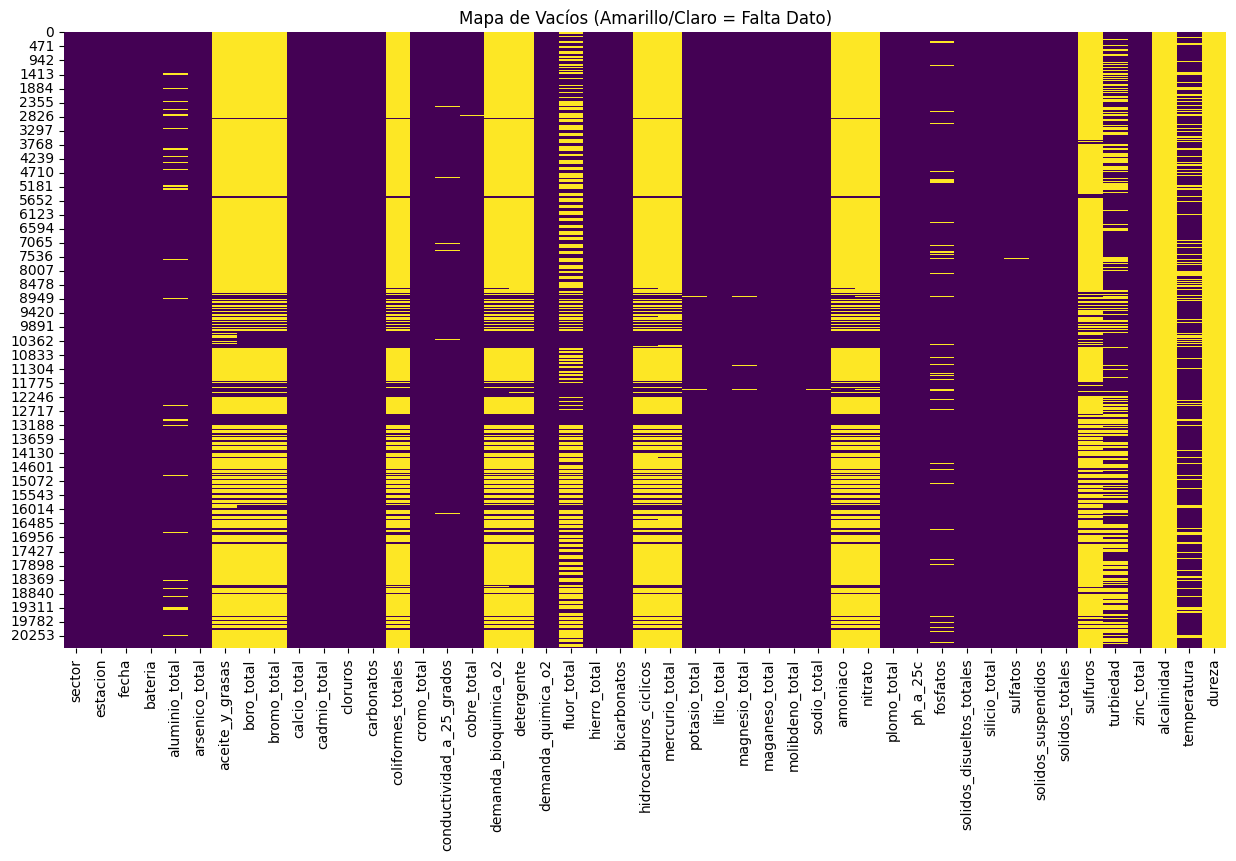

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar tu tabla final
df_audit= df_concat.copy()

# 2. CÁLCULO GLOBAL
total_celdas = df_audit.size
total_llenos = df_audit.count().sum() # count() ignora NaNs
porcentaje_global = (total_llenos / total_celdas) * 100

print(f"📊 REPORTE DE CAPTURA")
print(f"====================")
print(f"Total de Celdas: {total_celdas}")
print(f"Celdas con Datos: {total_llenos}")
print(f"Celdas Vacías: {total_celdas - total_llenos}")
print(f"🚀 PORCENTAJE DE CAPTURA GLOBAL: {porcentaje_global:.2f}%")

# 3: PORCENTAJE POR COLUMNA
# Esto te dirá qué columnas específicas fallaron o están vacías
info_cols = pd.DataFrame({
    'Llenos': df_audit.count(),
    'Vacios': df_audit.isnull().sum(),
    '% Captura': (df_audit.count() / len(df_audit)) * 100
})

print("\n--- Detalle por Columna (Las más bajas primero) ---")
print(info_cols.sort_values('% Captura').head(10))

# PASO 4: MAPA DE CALOR VISUAL
# Verás tus datos: Negro = Dato, Blanco/Claro = Vacío
plt.figure(figsize=(15, 8))
sns.heatmap(df_audit.isnull(), cbar=False, cmap='viridis') 
plt.title("Mapa de Vacíos (Amarillo claro = Falta Dato)")
plt.show()

## Creación de análisis descriptivo y cardinalidad

In [ ]:

df1.describe().to_excel("DESCRIPTIVOS_ANEXO_A.xlsx", index=True)
df2.describe().to_excel("DESCRIPTIVOS_ANEXO_B.xlsx", index=True)
df3.describe().to_excel("DESCRIPTIVOS_ANEXO_C.xlsx", index=True)

In [ ]:
import pandas as pd

lista_dfs = [df1, df2, df3]
lista_anexos = ['ANEXO_A', 'ANEXO_B', 'ANEXO_C']

# 1. Definimos la lista de columnas que quieres contar
columnas_a_contar = [
    'aluminio_total', 'arsenico_total', 'aceite_y_grasas', 'boro_total', 'bromo_total',
    'calcio_total', 'cadmio_total', 'cloruros', 'carbonatos',
    'coliformes_totales', 'cromo_total', 'conductividad_a_25_grados',
    'cobre_total', 'demanda_bioquimica_o2', 'detergente',
    'demanda_quimica_o2', 'fluor_total', 'hierro_total', 'bicarbonatos',
    'hidrocarburos_ciclicos', 'mercurio_total', 'potasio_total',
    'litio_total', 'magnesio_total', 'maganeso_total', 'molibdeno_total',
    'sodio_total', 'amoniaco', 'nitrato', 'plomo_total', 'ph_a_25c',
    'fosfatos', 'solidos_disueltos_totales', 'silicio_total', 'sulfatos',
    'solidos_suspendidos', 'solidos_totales', 'sulfuros', 'turbiedad',
    'zinc_total', 'alcalinidad', 'temperatura', 'dureza'
]

# 2. Creamos un diccionario de reglas de agregación (el "mapa" de qué hacer con cada columna)
agregaciones = { 'fecha': ['min', 'max'] }

for col in columnas_a_contar:
    agregaciones[col] = 'count'

for df, nombre_anexo in zip(lista_dfs, lista_anexos):
    # 3. Ejecutamos la agrupación
    # Agrupamos por 'sector'.
    resultado = df.groupby('estacion').agg(agregaciones)

    # 4. (Opcional) Aplanar los nombres de las columnas para que queden prolijos 
    # (ej: fecha_min, fecha_max, aluminio_total_count)
    resultado.columns = ['_'.join(col).strip() for col in resultado.columns.values]
    resultado = resultado.reset_index()

    # Ver el resultado
    print(resultado)
    resultado.to_excel(f"CARDINALIDAD_{nombre_anexo}.xlsx", index=False)

   estacion   fecha_min   fecha_max  aluminio_total_count  \
0     CC-15  2007-07-31  2016-08-10                   113   
1     CC-17  2007-02-02  2016-08-01                   174   
2     CC-18  2007-05-31  2016-08-02                   161   
3      CC-2  2007-01-16  2016-08-11                   191   
4      CC-5  2007-06-01  2016-08-01                   143   
5      CC-7  2007-06-29  2016-08-02                   117   
6      CC-9  2007-03-17  2016-08-10                   173   
7     OT-03  2009-01-16  2016-08-23                   104   
8     OT-06  2009-07-14  2016-08-24                    89   
9     OT-08  2009-05-30  2016-08-02                    98   
10    OT-11  2009-04-08  2016-08-08                   153   
11    OT-13  2009-06-28  2016-08-24                    87   
12    OT-14  2009-06-28  2016-08-23                   145   
13    OT-18  2009-06-30  2015-08-20                    94   
14    OT-19  2010-01-14  2016-08-03                   137   
15    OT-20  2010-01-14 